<a href="https://colab.research.google.com/github/lawqh14/kyouth_program/blob/main/K_Youth_Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
from sklearn.linear_model import LinearRegression
import kagglehub
import os

In [ ]:
# Load the dataset directly from Kaggle
path = kagglehub.dataset_download("yasserh/walmart-dataset")
# print(os.listdir(path))

#Convert to DF
df = pd.read_csv(f"{path}/Walmart.csv")

#Checking size of df
print("\n Checking dataframe size \n")
print(f"This dataframe contains {df.shape[0]} rows & {df.shape[1]} columns")

#Peek at data
print("\n Peeking at top 5 rows \n")
print(df.head())

#Sanity check on data for identifying odd data
print("\n Randomly sampling the rows \n")
print(df.sample(5))

Using Colab cache for faster access to the 'walmart-dataset' dataset.

 Checking dataframe size 

This dataframe contains 6435 rows & 8 columns

 Peeking at top 5 rows 

   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  

 Randomly sampling the rows 

      Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
1631     12  18-03-2011    1009502.01             0        64.21       3.692

In [ ]:
#Check column names
print(f"Column names are {df.columns.tolist()}")
print("\n")
#Check column datatypes
print(df.dtypes)

Column names are ['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']


Store             int64
Date             object
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object


In [ ]:
#Check for Duplicates
print(df.duplicated().sum())

0


In [ ]:
#Check for Nulls
print("Number of nulls by column")
print(df.isna().sum())

Number of nulls by column
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


In [ ]:
#Generate summary stats for df
print("Getting summary stats for df")
print(df.describe())
print("\n Checking for count of unique values by column \n")
print(df.nunique())

Getting summary stats for df
             Store  Weekly_Sales  Holiday_Flag  Temperature   Fuel_Price  \
count  6435.000000  6.435000e+03   6435.000000  6435.000000  6435.000000   
mean     23.000000  1.046965e+06      0.069930    60.663782     3.358607   
std      12.988182  5.643666e+05      0.255049    18.444933     0.459020   
min       1.000000  2.099862e+05      0.000000    -2.060000     2.472000   
25%      12.000000  5.533501e+05      0.000000    47.460000     2.933000   
50%      23.000000  9.607460e+05      0.000000    62.670000     3.445000   
75%      34.000000  1.420159e+06      0.000000    74.940000     3.735000   
max      45.000000  3.818686e+06      1.000000   100.140000     4.468000   

               CPI  Unemployment  
count  6435.000000   6435.000000  
mean    171.578394      7.999151  
std      39.356712      1.875885  
min     126.064000      3.879000  
25%     131.735000      6.891000  
50%     182.616521      7.874000  
75%     212.743293      8.622000  
max   

In [ ]:
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [ ]:
# Sort by date
df = df.sort_values('Date')

In [ ]:
# Group by date and sum weekly sales across all stores
daily_sales = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

In [ ]:
# Get the last date in the dataset
last_date = daily_sales['Date'].max()

In [ ]:
# Define the past 3 months period
three_months_ago = last_date - timedelta(days=90)

In [ ]:
# Filter data for the past 3 months
past_3_months = daily_sales[daily_sales['Date'] >= three_months_ago]

In [ ]:
print(f"Dataset ends on: {last_date.strftime('%Y-%m-%d')}")
print(f"Using data from: {past_3_months['Date'].min().strftime('%Y-%m-%d')} to {past_3_months['Date'].max().strftime('%Y-%m-%d')}")
print(f"Number of weeks in past 3 months: {len(past_3_months)}")

Dataset ends on: 2012-10-26
Using data from: 2012-08-03 to 2012-10-26
Number of weeks in past 3 months: 13


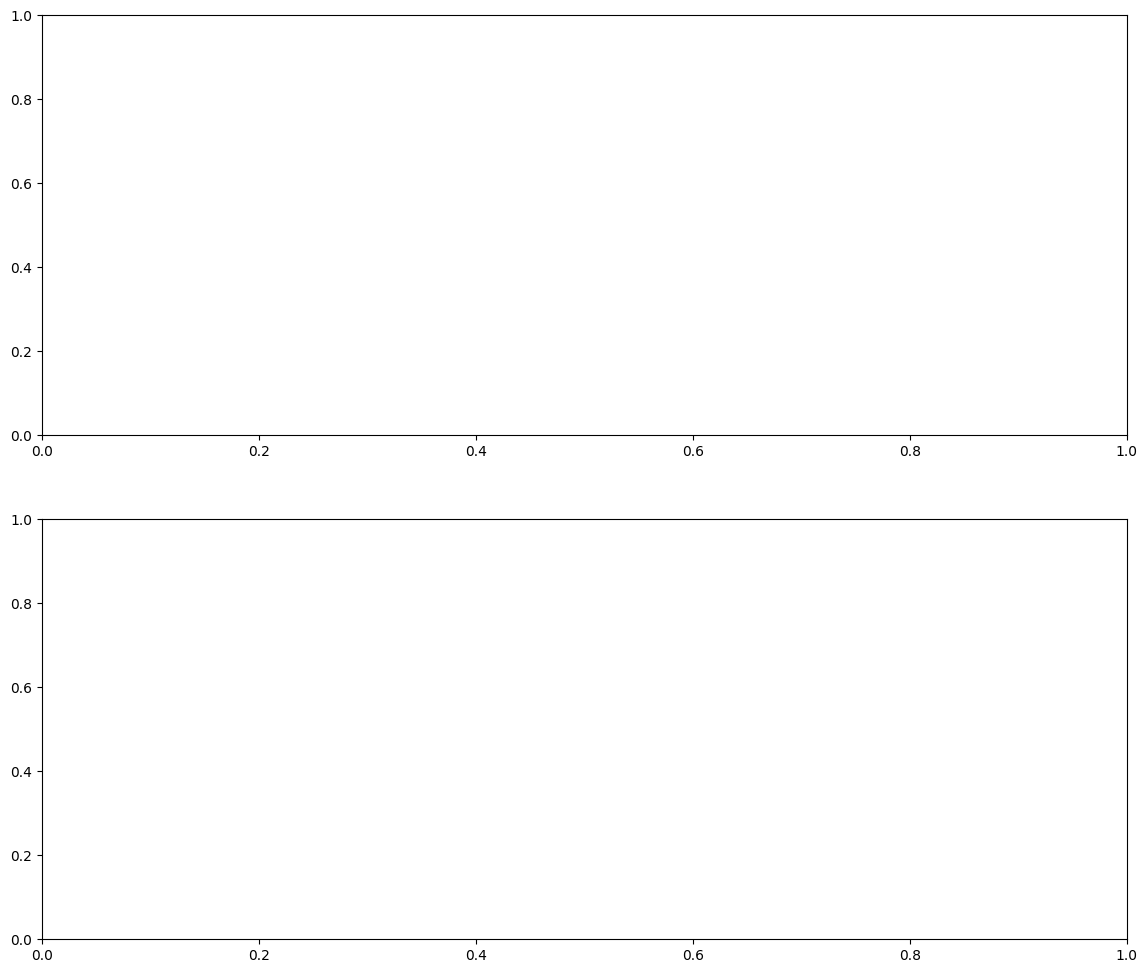

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

In [ ]:
# ============== PLOT 1: Past 3 Months Total Sales ==============
bars = ax1.bar(past_3_months['Date'], past_3_months['Weekly_Sales'],
               color='skyblue', edgecolor='navy', alpha=0.8)
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Total Weekly Sales ($)', fontsize=12)
ax1.set_title(f'Latest 3 Months Total Sales (All Stores Combined)\n{past_3_months["Date"].min().strftime("%b %Y")} - {past_3_months["Date"].max().strftime("%b %Y")}',
              fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Add total sales value on top of bars (show every bar since it's ~12-13 weeks)
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 50000,
             f'${height/1e6:.1f}M',
             ha='center', va='bottom', fontsize=8, rotation=0)


In [ ]:
# ============== PLOT 2: 3 Months Sales Projection ==============

# Prepare data for linear regression using the past 3 months
X = np.array(range(len(past_3_months))).reshape(-1, 1)
y = past_3_months['Weekly_Sales'].values

# Fit linear regression model
model = LinearRegression()
model.fit(X, y)

# Project for the next 3 months (approximately 12-13 weeks)
future_weeks = len(past_3_months)  # Project same number of weeks as we have data
X_future = np.array(range(len(past_3_months), len(past_3_months) + future_weeks)).reshape(-1, 1)
future_sales = model.predict(X_future)

# Create future dates
last_date = past_3_months['Date'].max()
future_dates = [last_date + timedelta(days=7*i) for i in range(1, future_weeks + 1)]

# Plot actual vs projected
ax2.plot(past_3_months['Date'], past_3_months['Weekly_Sales'],
         marker='o', color='blue', linewidth=2, label='Actual Sales (Past 3 Months)')

# Plot projected data
split_index = len(past_3_months)
ax2.plot(future_dates, future_sales,
         marker='s', color='red', linewidth=2, linestyle='--', label='Projected Sales (Next 3 Months)')

# Fill area under projection curve
ax2.fill_between(future_dates, 0, future_sales,
                 color='red', alpha=0.15)

ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Total Weekly Sales ($)', fontsize=12)
ax2.set_title('3 Months Sales Projection (Based on Latest 3 Months Trend)',
              fontsize=14, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# Add projection summary stats
avg_actual = np.mean(past_3_months['Weekly_Sales'])
avg_projected = np.mean(future_sales)
trend_pct = ((avg_projected - avg_actual) / avg_actual) * 100

stats_text = f'Data Period: {past_3_months["Date"].min().strftime("%b %Y")} - {past_3_months["Date"].max().strftime("%b %Y")}\n'
stats_text += f'Avg Weekly Sales (Actual): ${avg_actual/1e6:.2f}M\n'
stats_text += f'Projected Avg Weekly Sales: ${avg_projected/1e6:.2f}M\n'
stats_text += f'Projected Trend: {trend_pct:+.1f}%\n'
stats_text += f'R² Score: {model.score(X, y):.3f}'

ax2.text(0.02, 0.95, stats_text, transform=ax2.transAxes,
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('sales_analysis_projection.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
# ============== Print Summary Statistics ==============
print("\n" + "=" * 70)
print("SALES ANALYSIS SUMMARY - LATEST 3 MONTHS")
print("=" * 70)

print(f"\nDataset Date Range: {daily_sales['Date'].min().strftime('%Y-%m-%d')} to {daily_sales['Date'].max().strftime('%Y-%m-%d')}")
print(f"Total Stores: {df['Store'].nunique()}")
print(f"Total Records: {len(df)}")

print(f"\n--- LATEST 3 MONTHS ({past_3_months['Date'].min().strftime('%Y-%m-%d')} to {past_3_months['Date'].max().strftime('%Y-%m-%d')}) ---")
print(f"Total Sales: ${past_3_months['Weekly_Sales'].sum():,.0f}")
print(f"Average Weekly Sales: ${past_3_months['Weekly_Sales'].mean():,.0f}")
print(f"Max Weekly Sales: ${past_3_months['Weekly_Sales'].max():,.0f}")
print(f"Min Weekly Sales: ${past_3_months['Weekly_Sales'].min():,.0f}")

print(f"\n--- 3 MONTHS PROJECTION ({future_dates[0].strftime('%Y-%m-%d')} to {future_dates[-1].strftime('%Y-%m-%d')}) ---")
print(f"Projected Total Sales: ${sum(future_sales):,.0f}")
print(f"Projected Average Weekly Sales: ${avg_projected:,.0f}")
print(f"Projected Trend: {trend_pct:+.1f}%")
print(f"Model R² Score: {model.score(X, y):.3f} (closer to 1 = better fit)")

print("\n" + "=" * 70)

# Check which months were actually used
print("\nWeeks included in the analysis:")
for idx, row in past_3_months.iterrows():
    print(f"  {row['Date'].strftime('%Y-%m-%d')}: ${row['Weekly_Sales']:,.0f}")


SALES ANALYSIS SUMMARY - LATEST 3 MONTHS

Dataset Date Range: 2010-02-05 to 2012-10-26
Total Stores: 45
Total Records: 6435

--- LATEST 3 MONTHS (2012-08-03 to 2012-10-26) ---
Total Sales: $601,857,991
Average Weekly Sales: $46,296,769
Max Weekly Sales: $48,330,059
Min Weekly Sales: $43,734,899

--- 3 MONTHS PROJECTION (2012-11-02 to 2013-01-25) ---
Projected Total Sales: $566,176,056
Projected Average Weekly Sales: $43,552,004
Projected Trend: -5.9%
Model R² Score: 0.288 (closer to 1 = better fit)


Weeks included in the analysis:
  2012-08-03: $47,485,900
  2012-08-10: $47,403,451
  2012-08-17: $47,354,452
  2012-08-24: $47,447,324
  2012-08-31: $47,159,639
  2012-09-07: $48,330,059
  2012-09-14: $44,226,039
  2012-09-21: $44,354,547
  2012-09-28: $43,734,899
  2012-10-05: $47,566,639
  2012-10-12: $46,128,514
  2012-10-19: $45,122,411
  2012-10-26: $45,544,116


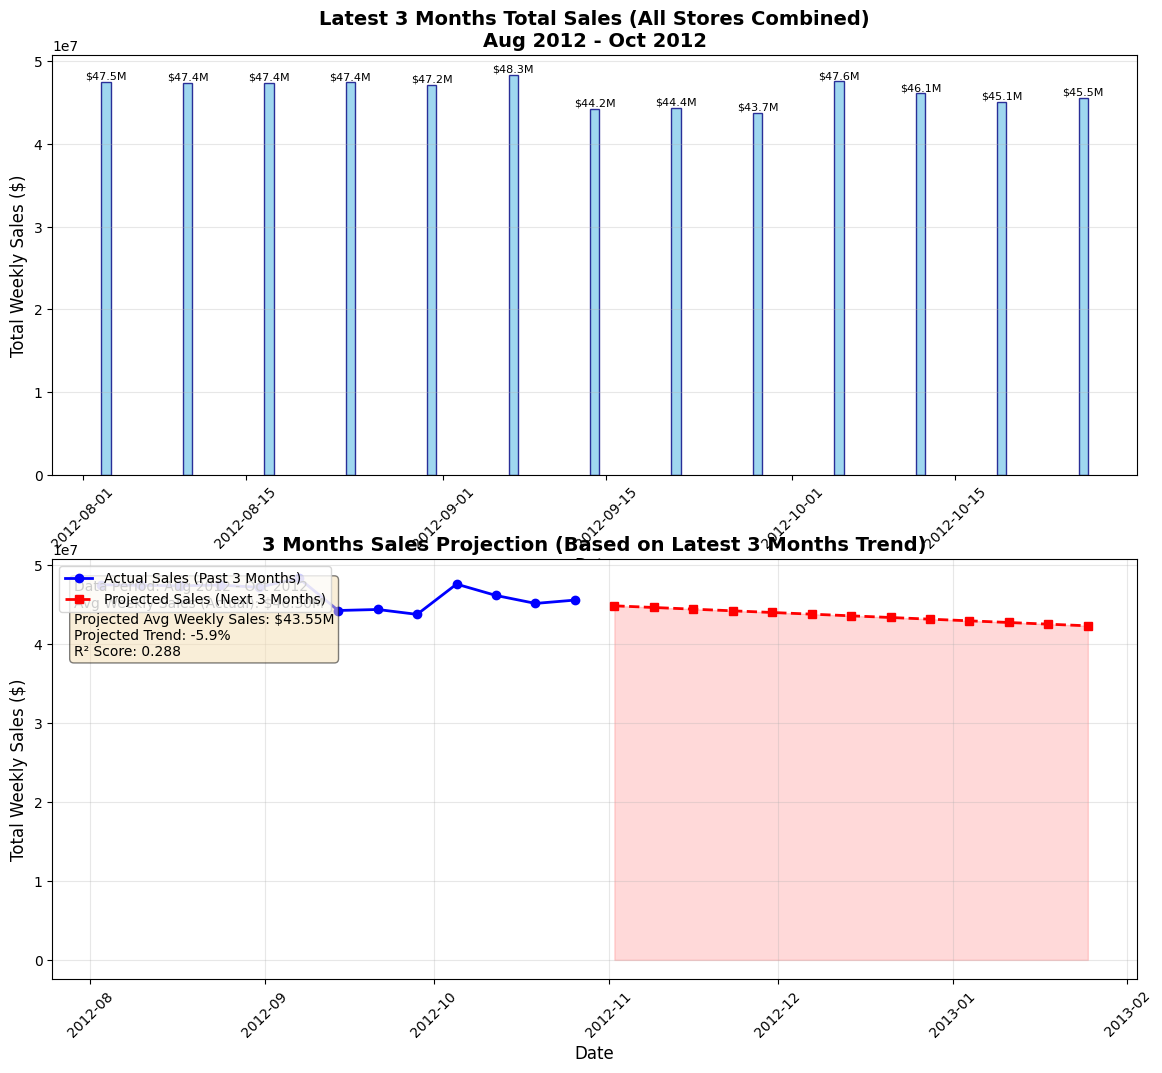

In [ ]:
fig

NEW CODE


Using Colab cache for faster access to the 'walmart-dataset' dataset.


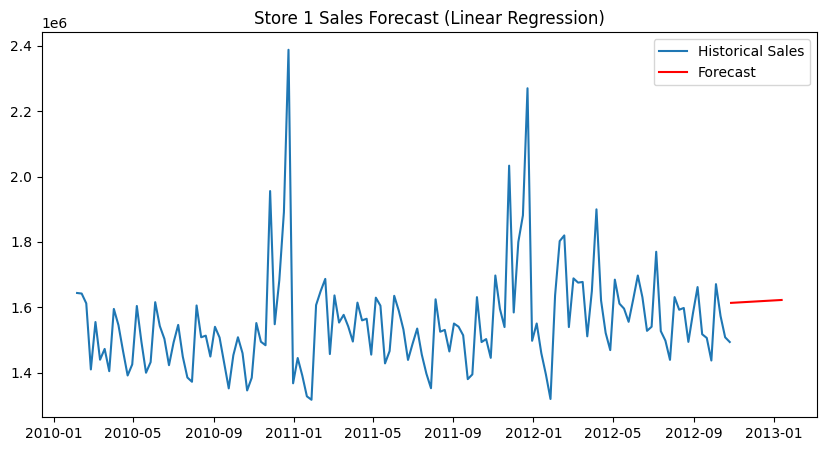


--- Past 3 Months Sales ---
2012-08-10 : 1,592,410
2012-08-17 : 1,597,868
2012-08-24 : 1,494,122
2012-08-31 : 1,582,083
2012-09-07 : 1,661,767
2012-09-14 : 1,517,429
2012-09-21 : 1,506,126
2012-09-28 : 1,437,059
2012-10-05 : 1,670,786
2012-10-12 : 1,573,073
2012-10-19 : 1,508,069
2012-10-26 : 1,493,660

--- Forecast Next 3 Months ---
2012-10-28 : 1,613,428
2012-11-04 : 1,614,236
2012-11-11 : 1,615,044
2012-11-18 : 1,615,852
2012-11-25 : 1,616,659
2012-12-02 : 1,617,467
2012-12-09 : 1,618,275
2012-12-16 : 1,619,083
2012-12-23 : 1,619,891
2012-12-30 : 1,620,698
2013-01-06 : 1,621,506
2013-01-13 : 1,622,314


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np
import kagglehub

# 1. Load dataset
path = kagglehub.dataset_download("yasserh/walmart-dataset")
df = pd.read_csv(f"{path}/Walmart.csv")
# 2. Filter only Store 1 (first 146 rows)
store1 = df[df['Store'] == 1].head(146)

# 3. Convert Date column to datetime
store1['Date'] = pd.to_datetime(store1['Date'], format='%d-%m-%Y')

# 4. Reset index for regression
store1.reset_index(drop=True, inplace=True)

# 5. Prepare features (time index) and target (sales)
X = np.arange(len(store1)).reshape(-1, 1)   # time steps
y = store1['Weekly_Sales'].values

# 6. Train linear regression model
model = LinearRegression()
model.fit(X, y)

# 7. Forecast next 12 weeks (~3 months)
future_X = np.arange(len(store1), len(store1)+12).reshape(-1, 1)
future_pred = model.predict(future_X)

# 8. Plot results
plt.figure(figsize=(10,5))
plt.plot(store1['Date'], y, label="Historical Sales")
plt.plot(pd.date_range(store1['Date'].iloc[-1], periods=12, freq='W'), future_pred, label="Forecast", color="red")
plt.legend()
plt.title("Store 1 Sales Forecast (Linear Regression)")
plt.show()

# 9. Function to display past 3 months and forecast with formatting
def show_sales_summary(data, forecast, weeks=12):
    # Past 3 months (last 12 weeks)
    past_sales = data.tail(weeks)
    print("\n--- Past 3 Months Sales ---")
    for _, row in past_sales.iterrows():
        print(f"{row['Date'].date()} : {row['Weekly_Sales']:,.0f}")

    # Forecast next 3 months
    future_dates = pd.date_range(data['Date'].iloc[-1], periods=weeks, freq='W')
    print("\n--- Forecast Next 3 Months ---")
    for date, value in zip(future_dates, forecast):
        print(f"{date.date()} : {value:RM,.0f}")

# Call the summary function
show_sales_summary(store1, future_pred, weeks=12)